# Chapter 3 Companion — Quantum Gates and Circuits

Runnable companions to the worked examples in
[`docs/03_quantum_gates_and_circuits`](../docs/03_quantum_gates_and_circuits):

- [`01_single_qubit_gates.md`](../docs/03_quantum_gates_and_circuits/01_single_qubit_gates.md)
- [`03_circuit_model_and_universality.md`](../docs/03_quantum_gates_and_circuits/03_circuit_model_and_universality.md)

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
S = np.array([[1, 0], [0, 1j]], dtype=complex)
T = np.array([[1, 0], [0, np.exp(1j*np.pi/4)]], dtype=complex)

def Rx(t): return np.cos(t/2)*I2 - 1j*np.sin(t/2)*X
def Ry(t): return np.cos(t/2)*I2 - 1j*np.sin(t/2)*Y
def Rz(t): return np.cos(t/2)*I2 - 1j*np.sin(t/2)*Z

def equal_up_to_phase(A, B):
    '''True if A = e^{i phi} B for some global phase phi.'''
    idx = np.unravel_index(np.argmax(np.abs(B)), B.shape)
    phase = A[idx] / B[idx]
    return np.isclose(abs(phase), 1) and np.allclose(A, phase * B)

## Example 1 — Gate-identity verification

*Docs: `01_single_qubit_gates.md`.* The workhorse identities, checked by direct matrix
arithmetic: the Hadamard conjugations `HXH = Z`, `HZH = X`, `HYH = −Y`; the Clifford
conjugations `SXS† = Y`, `SZS† = Z`; the phase-gate hierarchy `T² = S`, `S² = Z`, `T⁸ = I`;
and the *non*-Clifford signature `TXT† = (X+Y)/√2` — not a Pauli, which is exactly why T
escapes the Gottesman–Knill simulable set.

In [2]:
checks = {
    "H X H = Z":   np.allclose(H @ X @ H, Z),
    "H Z H = X":   np.allclose(H @ Z @ H, X),
    "H Y H = -Y":  np.allclose(H @ Y @ H, -Y),
    "S X S† = Y":  np.allclose(S @ X @ S.conj().T, Y),
    "S Z S† = Z":  np.allclose(S @ Z @ S.conj().T, Z),
    "T·T = S":     np.allclose(T @ T, S),
    "S·S = Z":     np.allclose(S @ S, Z),
    "T^8 = I":     np.allclose(np.linalg.matrix_power(T, 8), I2),
    "T·S·T = Z (Ex. 2, ch 3.3)": np.allclose(T @ S @ T, Z),
    "H = (X+Z)/√2": np.allclose(H, (X + Z)/np.sqrt(2)),
}
for name, ok in checks.items():
    print(f"{name:28s} {'✓' if ok else '✗'}")
assert all(checks.values())

TXTdg = T @ X @ T.conj().T
print("\nT X T† =\n", np.round(TXTdg, 4))
print("equals (X+Y)/√2:", np.allclose(TXTdg, (X + Y)/np.sqrt(2)),
      " -> not a Pauli operator, so T is NOT Clifford")
assert np.allclose(TXTdg, (X + Y)/np.sqrt(2))

H X H = Z                    ✓
H Z H = X                    ✓
H Y H = -Y                   ✓
S X S† = Y                   ✓
S Z S† = Z                   ✓
T·T = S                      ✓
S·S = Z                      ✓
T^8 = I                      ✓
T·S·T = Z (Ex. 2, ch 3.3)    ✓
H = (X+Z)/√2                 ✓

T X T† =
 [[0.    +0.j     0.7071-0.7071j]
 [0.7071+0.7071j 0.    +0.j    ]]
equals (X+Y)/√2: True  -> not a Pauli operator, so T is NOT Clifford


## Example 2 — `HTH = e^{iπ/8} R_x(π/4)` and decomposing `U = (1/√2)[[1,i],[i,1]]`

*Docs: `01_single_qubit_gates.md`, "Worked Example".* (a) Conjugating the z-rotation T by H
turns it into an x-rotation: `HTH = e^{iπ/8} R_x(π/4)`. (b) The unitary
`U = (1/√2)[[1,i],[i,1]]` is `R_x(−π/2)` and decomposes into Cliffords as
`U = e^{iπ/4} · H S† H`.

In [3]:
# (a) HTH vs Rx(pi/4)
HTH = H @ T @ H
target = np.exp(1j*np.pi/8) * Rx(np.pi/4)
print("HTH = e^{i pi/8} Rx(pi/4):", np.allclose(HTH, target))
assert np.allclose(HTH, target)

# (b) U decomposition
U = np.array([[1, 1j], [1j, 1]], dtype=complex) / np.sqrt(2)
print("U unitary:", np.allclose(U.conj().T @ U, I2), " det(U) =", np.linalg.det(U).round(6))
print("U = Rx(-pi/2):", np.allclose(U, Rx(-np.pi/2)))
decomp = np.exp(1j*np.pi/4) * (H @ S.conj().T @ H)
print("U = e^{i pi/4} H S† H:", np.allclose(U, decomp))
assert np.allclose(U, Rx(-np.pi/2)) and np.allclose(U, decomp)
print("H S† H alone implements U up to global phase:",
      equal_up_to_phase(H @ S.conj().T @ H, U))

HTH = e^{i pi/8} Rx(pi/4): True
U unitary: True  det(U) = (1+0j)
U = Rx(-pi/2): True
U = e^{i pi/4} H S† H: True
H S† H alone implements U up to global phase: True


## Example 3 — Why `{H, T}` is dense in SU(2): the THTH rotation angle

*Docs: `03_circuit_model_and_universality.md`, §"Why {H, T, CNOT} Is Universal" and Exercise 4.*
The composite `T·(HTH)` — a `π/4` z-rotation followed by a `π/4` x-rotation — is a rotation
by angle `θ` with `cos(θ/2) = cos²(π/8) = (2+√2)/4 ≈ 0.85355`, giving
`θ ≈ 0.348886·π`, an **irrational** multiple of π. Its powers therefore never cycle and fill
the rotation circle densely — the mechanism behind `{H,T}` universality. The docs also check
`Tr[R_z(π/4)R_x(π/4)] = (2+√2)/2 ≈ 1.70711`.

Tr = 1.7071067811865475  docs: (2+√2)/2 = 1.7071067811865475
cos(theta/2) = 0.85355 (docs: 0.85355)
theta = 1.09606 rad = 0.348886·pi (docs: 0.348886·pi)
  vs 1/3 = 0.333333 -> differs by 1.56e-02
  vs 3/8 = 0.375000 -> differs by 2.61e-02
  vs 7/20 = 0.350000 -> differs by 1.11e-03


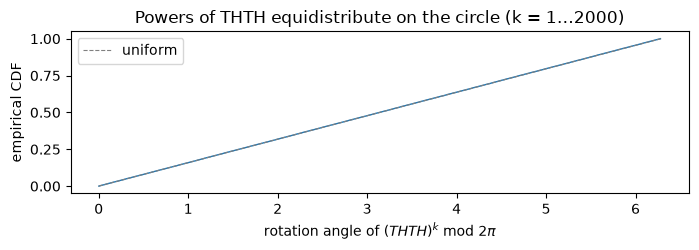

largest gap between consecutive angles after 2000 powers: 0.0069 rad


In [4]:
comp = Rz(np.pi/4) @ Rx(np.pi/4)            # SU(2) representative of T·(HTH)
tr = np.trace(comp)
print("Tr =", tr.real, " docs: (2+√2)/2 =", (2 + np.sqrt(2))/2)
assert np.isclose(tr.real, (2 + np.sqrt(2))/2) and np.isclose(tr.imag, 0)

cos_half = tr.real / 2
theta = 2 * np.arccos(cos_half)
print(f"cos(theta/2) = {cos_half:.5f} (docs: 0.85355)")
print(f"theta = {theta:.5f} rad = {theta/np.pi:.6f}·pi (docs: 0.348886·pi)")
assert np.isclose(theta/np.pi, 0.348886, atol=1e-5)
for frac, val in [("1/3", 1/3), ("3/8", 3/8), ("7/20", 7/20)]:
    print(f"  vs {frac} = {val:.6f} -> differs by {abs(theta/np.pi - val):.2e}")

# Density experiment: the angles of powers (THTH)^k fill the circle
angles = (np.arange(1, 2001) * theta) % (2 * np.pi)
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.plot(np.sort(angles), np.linspace(0, 1, len(angles)), lw=1)
ax.plot([0, 2*np.pi], [0, 1], "--", color="gray", lw=0.8, label="uniform")
ax.set_xlabel(r"rotation angle of $(THTH)^k$ mod $2\pi$")
ax.set_ylabel("empirical CDF")
ax.set_title("Powers of THTH equidistribute on the circle (k = 1…2000)")
ax.legend(); fig.tight_layout(); plt.show()
gaps = np.diff(np.sort(angles))
print(f"largest gap between consecutive angles after 2000 powers: {gaps.max():.4f} rad")

## Example 4 — Stabilizer tracking: the Bell circuit and `H⊗H⊗H`

*Docs: `03_circuit_model_and_universality.md`, "Worked Example" + Exercise 1.* Tracking
stabilizer generators instead of amplitudes (the Gottesman–Knill simulation in miniature):

- `|000⟩` stabilized by `{Z₁,Z₂,Z₃}` → after `H^{⊗3}`, by `{X₁,X₂,X₃}` (state `|+++⟩`).
- `|00⟩` stabilized by `{Z₁,Z₂}` → after `H₁` then `CNOT₁₂`, by `{X₁X₂, Z₁Z₂}` — the
  stabilizers of the Bell state `|Φ⁺⟩`.

We verify with `qiskit.quantum_info.StabilizerState` and check the generators directly.

In [5]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import StabilizerState, Statevector, Pauli

# H on all three qubits
qc3 = QuantumCircuit(3)
qc3.h([0, 1, 2])
stab3 = StabilizerState(qc3)
print("H⊗3 |000> stabilizer generators:", stab3.clifford.to_labels(mode="S"))

sv3 = Statevector(qc3)
print("uniform superposition amplitudes:", np.allclose(sv3.data, np.ones(8)/np.sqrt(8)))
assert np.allclose(sv3.data, np.ones(8)/np.sqrt(8))

# Bell circuit
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
stabB = StabilizerState(bell)
gens = stabB.clifford.to_labels(mode="S")
print("Bell state stabilizer generators:", gens, " (docs: {X1X2, Z1Z2})")
assert set(gens) == {"+XX", "+ZZ"}

# direct check: XX and ZZ both fix |Phi+>
phi_plus = Statevector(bell)
for label in ["XX", "ZZ"]:
    fixed = phi_plus.evolve(Pauli(label))
    print(f"{label}|Φ+> = |Φ+>:", np.allclose(fixed.data, phi_plus.data))
    assert np.allclose(fixed.data, phi_plus.data)

H⊗3 |000> stabilizer generators: ['+IIX', '+IXI', '+XII']
uniform superposition amplitudes: True
Bell state stabilizer generators: ['+XX', '+ZZ']  (docs: {X1X2, Z1Z2})
XX|Φ+> = |Φ+>: True
ZZ|Φ+> = |Φ+>: True


## Example 5 — Error composition and the T-count of compiled rotations

*Docs: `03_circuit_model_and_universality.md`, Exercise 3.* Unitary errors add at worst
linearly: `‖U₂U₁ − V₂V₁‖ ≤ ε₁ + ε₂`. For a circuit of `10⁶` rotations and total budget
`10⁻³`, each rotation needs `ε = 10⁻⁹`, costing `≈ 3·log₂(1/ε) ≈ 90` T gates per rotation
(Ross–Selinger), i.e. ~`10⁸` T gates overall. We verify the additivity bound numerically on
random unitaries and reproduce the budget arithmetic.

In [6]:
rng = np.random.default_rng(42)

def random_su2(scale=1.0):
    a = scale * rng.normal(size=3)
    n = np.linalg.norm(a)
    axis = a / n if n > 0 else np.array([1, 0, 0])
    return np.cos(n/2)*I2 - 1j*np.sin(n/2)*(axis[0]*X + axis[1]*Y + axis[2]*Z)

def opnorm(A):
    return np.linalg.norm(A, 2)

# empirical check of ||U2 U1 - V2 V1|| <= ||U1-V1|| + ||U2-V2||
violations = 0
for _ in range(500):
    U1, U2 = random_su2(), random_su2()
    V1 = U1 @ random_su2(0.05)          # small perturbations
    V2 = U2 @ random_su2(0.05)
    lhs = opnorm(U2 @ U1 - V2 @ V1)
    rhs = opnorm(U1 - V1) + opnorm(U2 - V2)
    if lhs > rhs + 1e-12:
        violations += 1
print("triangle-bound violations in 500 random trials:", violations)
assert violations == 0

# budget arithmetic from the docs
n_gates, total_budget = 1e6, 1e-3
eps = total_budget / n_gates
t_per_rot = 3 * np.log2(1/eps)
print(f"per-gate precision  eps = {eps:.0e}")
print(f"T gates per rotation ≈ 3·log2(1/eps) = {t_per_rot:.1f}  (docs: ≈ 90)")
print(f"total T gates ≈ {n_gates * t_per_rot:.2e}  (docs: ~1e8)")
assert 89 < t_per_rot < 91

triangle-bound violations in 500 random trials: 0
per-gate precision  eps = 1e-09
T gates per rotation ≈ 3·log2(1/eps) = 89.7  (docs: ≈ 90)
total T gates ≈ 8.97e+07  (docs: ~1e8)
